# Preprocessing as an SLSQP warm-start

Today, the iterative SLSQP solvers in `dvfopt/core/slsqp/` hand the raw folded `phi` to SciPy as both the starting iterate and the L2 anchor. This notebook tests whether **preprocessing the field** — specifically scaling down displacement vectors at pixels that participate in folded cells — gives SLSQP a better starting point.

**Strict warm-start framing.** The L2/L1 *target* (anchor) stays at `phi_original` for every run. Only the *starting iterate* `phi_start` changes. This isolates "preprocessing as a warm-start" from "preprocessing as a different optimum".

**Strategies compared.**
- **S0 baseline** — start at `phi_original`. Current behavior.
- **S1 global α-bisection** — scale all of `phi_original` by the largest `α ∈ [0, 1]` for which `α · phi` is feasible. Single-knob, cheapest preprocessing.
- **S2 pixel-level scaling** *(the user's idea)* — find fold-participating pixels via `find_problematic_pixels`; scale their `(dy, dx)` by `s ∈ {0.0, 0.25, 0.5, 0.75}`; leave other pixels untouched. `find_problematic_pixels` returns *one corner pixel per inverted triangle*, so this is a sparse modification.
- **S3 cell-vertex scaling** — find folded cells via `triangle_sign_areas2D`; scale the **4-vertex stencil** of each folded cell by `s`. **Distinct from S2:** S3 always touches all 4 vertices of every folded cell, while S2 only touches 1 pixel per inverted triangle. On the bowtie, S2 modifies 2 pixels and S3 modifies 6 pixels for the same scale factor. We compare them empirically.

**Objectives compared.** L2 (`objective_euc`) and smoothed L1 (`Σ √(Δ² + ε²)`, `ε = 1e-4`) — same formulations as `09_horizontal-vs-diagonal-bowtie.ipynb`.

**Decision rule.** A strategy is "worth defaulting on" for a given objective iff, on at least 2 of 3 test cases:
1. `final_min_tr ≥ THRESHOLD − 1e-9` (no constraint violation).
2. `final_norm ≤ 1.01 × baseline_final_norm` (no L1/L2 regression beyond ~1%).
3. `nit ≤ 0.7 × baseline_nit` *or* `t ≤ 0.7 × baseline_t` (≥30% reduction in iteration count or wall-clock).
4. `success` whenever baseline succeeds, plus at least one rescue case where baseline fails.

**Pitfalls to keep in mind.** Both objectives are strictly convex, the constraint is locally convex; for easy cases all strategies converge to the same `phi_final`. Wins live in `nit`, `t`, and rescues — not `final_norm`. The bowtie is too small to show meaningful runtime deltas; the two 10×10 cases drive the wall-clock comparison. Full-grid SLSQP is impractical past ~10×10 (a 20×20 case under the same setup takes minutes per strategy); the takeaways here generalize, but production-scale fields would use the windowed iterative solver in `dvfopt`.

In [1]:
import os, sys, time, io, contextlib, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.viz.triangle_debug import find_problematic_pixels
from dvfopt.core.objective import objective_euc
import test_cases

THRESHOLD = DEFAULT_PARAMS['threshold']
EPS_L1 = 1e-4  # smoothing parameter for L1 objective
print(f'THRESHOLD = {THRESHOLD},  EPS_L1 = {EPS_L1}')

THRESHOLD = 0.01,  EPS_L1 = 0.0001


In [2]:
def _l2(phi, anchor):
    return float(np.linalg.norm(phi - anchor))

def _l1(phi, anchor):
    return float(np.abs(phi - anchor).sum())

def report(phi, phi_anchor, label):
    jd = np.squeeze(jacobian_det2D(phi))
    tri = triangle_sign_areas2D(phi)
    return {
        'label': label,
        'jd': jd, 'tri': tri,
        'n_tr': int((tri <= 0).sum()),
        'min_tr': float(tri.min()),
        'min_cd': float(jd.min()),
        'l2': _l2(phi, phi_anchor),
        'l1': _l1(phi, phi_anchor),
        'phi': phi,
    }

def _triangle_flat(dy, dx):
    T1, T2 = _triangle_areas_2d(dy, dx)
    return np.concatenate([T1.flatten(), T2.flatten()])

## Preprocessing helpers

Each helper returns `(phi_start, meta)` where `meta` carries `modified_pixels` (`(y, x)` tuples) and `modified_cells` (`(cy, cx)` tuples), so the visualization cell can highlight exactly what was touched without re-deriving the footprint from the diff field. **S2 and S3 are distinct strategies** — see the intro for why.

In [3]:
def preprocess_baseline(phi):
    """S0 — return phi unchanged."""
    return phi.copy(), {
        'name': 'S0', 'params': {},
        'modified_pixels': [], 'modified_cells': [],
    }


def preprocess_global_alpha(phi, threshold=THRESHOLD, tol=1e-4, max_iter=40):
    """S1 — find smallest alpha in [0, 1] s.t. min(triangle_sign_areas2D(alpha*phi)) >= threshold.
    Bisection between alpha_lo (infeasible) and alpha_hi (feasible)."""
    if triangle_sign_areas2D(phi).min() >= threshold:
        # Already feasible — no scaling needed.
        H, W = phi.shape[1:]
        return phi.copy(), {
            'name': 'S1', 'params': {'alpha': 1.0},
            'modified_pixels': [], 'modified_cells': [],
        }
    lo, hi = 0.0, 1.0
    # Make sure alpha=0 is feasible (zero displacement -> identity, all triangles = 0.5).
    assert triangle_sign_areas2D(0.0 * phi).min() >= threshold, 'zero-DVF should be feasible'
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        if triangle_sign_areas2D(mid * phi).min() >= threshold:
            lo = mid  # mid is feasible — try a larger alpha
        else:
            hi = mid
        if hi - lo < tol:
            break
    alpha = lo  # largest known feasible
    phi_start = alpha * phi
    H, W = phi.shape[1:]
    # All non-zero pixels are modified; mark them.
    nonzero = np.where(np.linalg.norm(phi, axis=0) > 0)
    modified_pixels = list(zip(nonzero[0].tolist(), nonzero[1].tolist()))
    cells = set()
    for (y, x) in modified_pixels:
        for cy in (y - 1, y):
            for cx in (x - 1, x):
                if 0 <= cy < H - 1 and 0 <= cx < W - 1:
                    cells.add((cy, cx))
    return phi_start, {
        'name': 'S1', 'params': {'alpha': float(alpha)},
        'modified_pixels': modified_pixels,
        'modified_cells': sorted(cells),
    }


def preprocess_pixel_scale(phi, scale, threshold=THRESHOLD):
    """S2 — find fold-participating pixels via find_problematic_pixels(phi);
    multiply their (dy, dx) by `scale`. Note: returned tuples are (x, y)."""
    bad_xy = find_problematic_pixels(phi)  # list of (x, y)
    H, W = phi.shape[1:]
    phi_start = phi.copy()
    for (x, y) in bad_xy:
        phi_start[:, y, x] *= scale
    modified_pixels = sorted([(y, x) for (x, y) in bad_xy])
    cells = set()
    for (y, x) in modified_pixels:
        for cy in (y - 1, y):
            for cx in (x - 1, x):
                if 0 <= cy < H - 1 and 0 <= cx < W - 1:
                    cells.add((cy, cx))
    return phi_start, {
        'name': 'S2', 'params': {'scale': float(scale)},
        'modified_pixels': modified_pixels,
        'modified_cells': sorted(cells),
    }


def preprocess_cell_vertex_scale(phi, scale, threshold=THRESHOLD):
    """S3 — find folded cells, then scale the 4 vertex pixels of each folded cell."""
    tri = triangle_sign_areas2D(phi)
    folded_cells = np.argwhere(tri.min(axis=0) <= threshold)
    H, W = phi.shape[1:]
    pixels = set()
    for (cy, cx) in folded_cells:
        for dy_ in (0, 1):
            for dx_ in (0, 1):
                pixels.add((int(cy) + dy_, int(cx) + dx_))
    phi_start = phi.copy()
    for (y, x) in pixels:
        phi_start[:, y, x] *= scale
    return phi_start, {
        'name': 'S3', 'params': {'scale': float(scale)},
        'modified_pixels': sorted(pixels),
        'modified_cells': sorted([(int(cy), int(cx)) for (cy, cx) in folded_cells]),
    }

## SLSQP runners (L2 and L1)

The SLSQP problem is identical to `09_horizontal-vs-diagonal-bowtie.ipynb`: minimize a smooth objective over `z = [dx_flat | dy_flat]` subject to `T1 ≥ THRESHOLD` and `T2 ≥ THRESHOLD` per cell. The only knobs are (i) the *starting iterate* `phi_start` and (ii) the *objective form* (squared-L2 vs smoothed-L1). The L2/L1 *anchor* is always `phi_anchor = phi_original`.

In [4]:
def _pack(phi):
    return np.concatenate([phi[1].flatten(), phi[0].flatten()])

def _unpack(z, H, W):
    pixels = H * W
    return z[pixels:].reshape(H, W), z[:pixels].reshape(H, W)  # dy, dx


def _build_runner(objective):
    """Return a runner function for either 'l2' or 'l1' objective."""
    if objective == 'l2':
        def obj(z, z_anchor):
            return objective_euc(z, z_anchor)
    elif objective == 'l1':
        def obj(z, z_anchor):
            diff = z - z_anchor
            s = np.sqrt(diff * diff + EPS_L1 * EPS_L1)
            return float(s.sum()), diff / s
    else:
        raise ValueError(objective)

    # max_iter = 500 matches notebook 09's full-grid solver. The L2 bowtie
    # converges in ~6 iterations and the L2 10x10 cases in ~20-35, but the
    # smoothed-L1 bowtie genuinely needs ~259 iterations to drive max|dy|
    # back to zero (see 09_horizontal-vs-diagonal-bowtie.ipynb), so a tighter
    # cap yields false "diagonal-drift" results that look like SLSQP getting
    # stuck when it's actually just mid-trajectory.
    def runner(phi_anchor, phi_start, threshold=THRESHOLD, max_iter=500, label=''):
        _, H, W = phi_anchor.shape
        z_anchor = _pack(phi_anchor)
        z_start = _pack(phi_start)

        def constr(z):
            dy, dx = _unpack(z, H, W)
            return _triangle_flat(dy, dx)

        t0 = time.time()
        res = minimize(
            lambda z: obj(z, z_anchor),
            z_start.copy(), jac=True, method='SLSQP',
            constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
            options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False},
        )
        elapsed = time.time() - t0
        dy_out, dx_out = _unpack(res.x, H, W)
        phi_final = np.stack([dy_out, dx_out])

        rep = report(phi_final, phi_anchor, label)
        rep_init = report(phi_start, phi_anchor, label + ' (start)')
        rep.update(
            init_l2=rep_init['l2'], init_l1=rep_init['l1'],
            init_min_tr=rep_init['min_tr'], init_n_tr=rep_init['n_tr'],
            final_l2=rep['l2'], final_l1=rep['l1'],
            final_min_tr=rep['min_tr'], final_n_tr=rep['n_tr'],
            t=elapsed, nit=res.nit, success=bool(res.success),
            status=int(res.status), message=str(res.message),
            objective=objective,
        )
        return rep
    return runner

run_slsqp_l2 = _build_runner('l2')
run_slsqp_l1 = _build_runner('l1')

## Test cases

Three folded fields, varying in localization and severity. We deliberately keep grids ≤ 10×10 because full-grid SLSQP scales poorly past that — a 20×20 case under the same setup takes minutes per strategy. The takeaways here generalize; for production-scale fields you'd run the windowed iterative solver instead of full-grid SLSQP.

| name | shape | source | severity |
|---|---|---|---|
| **bowtie** | 7×7 | hand-crafted (same as `09`) | 2 folded triangles, very localized |
| **03a_10x10_opposite** | 10×10 | `test_cases.SYNTHETIC_CASES` | ~23 folded triangles, moderate |
| **03b_10x10_crossing** | 10×10 | `test_cases.SYNTHETIC_CASES` | ~28 folded triangles, slightly harder |

In [5]:
def _silent_make(case_key):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        df, _, _ = test_cases.make_deformation(case_key)
    return df[1:, 0]  # (3, 1, H, W) -> (2, H, W) channels [dy, dx]

# Case A: 7x7 bowtie
phi_bowtie = np.zeros((2, 7, 7))
phi_bowtie[1, 3, 3] = +1.2
phi_bowtie[1, 3, 4] = -1.2

# Case B: 10x10 synthetic opposite (moderate)
phi_10a = _silent_make('03a_10x10_opposite')

# Case C: 10x10 synthetic crossing (slightly harder than B)
phi_10b = _silent_make('03b_10x10_crossing')

CASES = [
    ('bowtie_7x7',    phi_bowtie),
    ('03a_10x10',     phi_10a),
    ('03b_10x10',     phi_10b),
]

for name, phi in CASES:
    rep = report(phi, phi, name)
    print(f'{name:<14s}  shape={phi.shape}  n_neg_tri={rep["n_tr"]:>4d}  min_tr={rep["min_tr"]:+.3f}  min_jd={rep["min_cd"]:+.3f}')

bowtie_7x7      shape=(2, 7, 7)  n_neg_tri=   2  min_tr=-0.700  min_jd=+0.400
03a_10x10       shape=(2, 10, 10)  n_neg_tri=  23  min_tr=-0.814  min_jd=-1.118
03b_10x10       shape=(2, 10, 10)  n_neg_tri=  28  min_tr=-0.700  min_jd=-1.039


## Visualization helpers

`plot_warped_grid` draws a deformed quad grid with folded cells outlined dark blue. `overlay_modifications` adds red-dot markers on modified vertices and green outlines on modified cells, so you can see exactly which pixels and quads each preprocessor touched. The actual progression figure (original → preprocessed → SLSQP-converged) is built later in [`plots-grids`](#plots-grids); this cell only defines helpers.

In [6]:
def plot_warped_grid(ax, phi, title, highlight_folds=True, fold_color='#1565c0',
                     title_fontsize=8):
    """Render the warped quad grid for a 2D DVF, outlining folded cells."""
    dy, dx = phi[0], phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color=fold_color, lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xticks([]); ax.set_yticks([])


def overlay_modifications(ax, phi_after, meta):
    """Mark which vertices/cells the preprocessor modified, on top of an existing warped-grid plot.

    Modified cells are outlined in green; modified vertices have a red dot at their deformed position.
    """
    dy, dx = phi_after[0], phi_after[1]
    H, W = dy.shape
    yy, xx = np.mgrid[:H, :W]
    gx = xx + dx; gy = yy + dy
    for (cy, cx) in meta['modified_cells']:
        px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#43a047', lw=1.5, alpha=0.85, zorder=4)
    for (y, x) in meta['modified_pixels']:
        ax.plot(gx[y, x], gy[y, x], 'o', color='#e53935', markersize=4, zorder=5,
                markeredgecolor='black', markeredgewidth=0.3)


def n_folded_cells(phi):
    return int((triangle_sign_areas2D(phi).min(axis=0) <= 0).sum())

## Run all (case × strategy × objective) combinations

Per case: run S0, S1, S2 (`s ∈ {0.0, 0.25, 0.5, 0.75}`), and S3 (same `s` set as S2). Each strategy is run under both L2 and smoothed-L1 objectives, anchored at `phi_original`. Total runs ≈ 10 strategies × 2 objectives × 3 cases = 60 SLSQP solves.

In [7]:
def strategy_grid():
    yield ('S0',                lambda p: preprocess_baseline(p))
    yield ('S1 alpha',          lambda p: preprocess_global_alpha(p))
    for s in (0.0, 0.25, 0.5, 0.75):
        yield (f'S2 pix s={s:.2f}',  lambda p, s=s: preprocess_pixel_scale(p, s))
        yield (f'S3 cell s={s:.2f}', lambda p, s=s: preprocess_cell_vertex_scale(p, s))


def _format_progress(strat_label, rl2, rl1):
    return ('    {0:<18s}  L2 ok={1} nit={2:3d} t={3:6.1f}ms   '
            'L1 ok={4} nit={5:3d} t={6:6.1f}ms').format(
        strat_label, rl2['success'], rl2['nit'], 1000 * rl2['t'],
        rl1['success'], rl1['nit'], 1000 * rl1['t'])


def _print_ranked(case_name, obj_label, rows):
    sub = [r for r in rows if r['objective'] == obj_label.lower()]
    baseline = next(r for r in sub if r['strategy'] == 'S0')
    sort_key = 'final_l2' if obj_label == 'L2' else 'final_l1'
    sub_sorted = sorted(sub, key=lambda r: (r[sort_key], r['nit']))
    print(f'\n=== {case_name}   objective={obj_label} ===')
    hdr = ('{0:<18s}  {1:>3s}  {2:>4s}  {3:>7s}  '
           '{4:>8s}  {5:>11s}  {6:>9s}  {7:>12s}  Dnit%   Dt%   Dnorm%').format(
        'strategy', 'ok', 'nit', 't(ms)', 'init_l2', 'init_min_tr',
        sort_key, 'final_min_tr')
    print(hdr); print('-' * len(hdr))
    for r in sub_sorted:
        d_nit = 100.0 * (r['nit'] - baseline['nit']) / max(baseline['nit'], 1)
        d_t   = 100.0 * (r['t'] - baseline['t']) / max(baseline['t'], 1e-6)
        d_nrm = 100.0 * (r[sort_key] - baseline[sort_key]) / max(baseline[sort_key], 1e-9)
        print(('{0:<18s}  {1:>3s}  {2:>4d}  {3:>7.1f}  '
               '{4:>8.3f}  {5:>+11.3f}  {6:>9.3f}  {7:>+12.3f}  '
               '{8:>+5.0f}  {9:>+5.0f}  {10:>+6.1f}').format(
            r['strategy'], str(r['success']), r['nit'], 1000 * r['t'],
            r['init_l2'], r['init_min_tr'], r[sort_key], r['final_min_tr'],
            d_nit, d_t, d_nrm))


results = {}
for case_name, phi in CASES:
    rows = []
    print(f'>>> {case_name} ...', flush=True)
    case_t0 = time.time()
    for strat_label, fn in strategy_grid():
        phi_start, meta = fn(phi)
        for obj_label, runner in (('L2', run_slsqp_l2), ('L1', run_slsqp_l1)):
            r = runner(phi, phi_start, label=f'{case_name}|{strat_label}|{obj_label}')
            r['strategy'] = strat_label
            r['case'] = case_name
            r['meta'] = meta
            r['phi_start'] = phi_start
            rows.append(r)
        print(_format_progress(strat_label, rows[-2], rows[-1]), flush=True)
    print(f'<<< {case_name}  done in {time.time() - case_t0:.1f}s', flush=True)
    results[case_name] = rows
    _print_ranked(case_name, 'L2', rows)
    _print_ranked(case_name, 'L1', rows)

>>> bowtie_7x7 ...
    S0                  L2 ok=True nit=  6 t=  26.4ms   L1 ok=True nit=259 t= 871.2ms
    S1 alpha            L2 ok=True nit=  7 t=  24.2ms   L1 ok=True nit=  4 t=  14.5ms
    S2 pix s=0.00       L2 ok=True nit=  9 t=  30.0ms   L1 ok=True nit= 67 t= 237.5ms
    S3 cell s=0.00      L2 ok=True nit=  8 t=  31.4ms   L1 ok=True nit=114 t= 395.2ms
    S2 pix s=0.25       L2 ok=True nit= 10 t=  33.7ms   L1 ok=True nit= 71 t= 219.7ms
    S3 cell s=0.25      L2 ok=True nit=  8 t=  26.1ms   L1 ok=True nit= 22 t=  66.7ms
    S2 pix s=0.50       L2 ok=True nit=  9 t=  29.7ms   L1 ok=True nit=150 t= 484.1ms
    S3 cell s=0.50      L2 ok=True nit=  8 t=  32.5ms   L1 ok=True nit= 14 t=  49.3ms
    S2 pix s=0.75       L2 ok=True nit=  9 t=  32.4ms   L1 ok=True nit=138 t= 465.7ms
    S3 cell s=0.75      L2 ok=True nit=  9 t=  34.6ms   L1 ok=True nit= 24 t=  84.9ms
<<< bowtie_7x7  done in 3.2s

=== bowtie_7x7   objective=L2 ===
strategy             ok   nit    t(ms)   init_l2  init_mi

## Field evolution per strategy: original → preprocessed → SLSQP-converged

One figure per test case. Each **row** is a single preprocessing strategy. Each **column** shows the warped grid at one stage of the pipeline:

| col | what it shows |
|---|---|
| 1 | **Before preprocessing** — the original folded `phi_anchor` (identical across all rows; included for direct visual comparison). |
| 2 | **After preprocessing** — `phi_start` produced by the row's strategy. Modified vertices are red dots; modified cells are green outlines; any *remaining* folds (cells the preprocessor did not fully repair) are dark-blue outlines. |
| 3 | **After SLSQP (L2) — NO preprocessing** — the converged iterate when SLSQP minimises L2 starting from the *raw* input (i.e., the S0 baseline result). Identical across all rows; placed here as the direct comparison point for column 4. |
| 4 | **After SLSQP (L2) — WITH this row's preprocessing** — converged iterate when SLSQP minimises L2 starting from the column-2 preprocessed field. |
| 5 | **After SLSQP (L1) — NO preprocessing** — same as col 3 but smoothed-L1 objective (the S0 baseline result for L1). Identical across all rows. |
| 6 | **After SLSQP (L1) — WITH this row's preprocessing** — converged iterate when SLSQP minimises smoothed L1 from the column-2 preprocessed field. |

The strategy rows shown are S0 (no preprocessing — control), S1 alpha-bisection, S2 pixel-scaling at `s = 0.5` (the user's idea, mid scale), and S3 cell-vertex scaling at `s = 0.5`. For the S0 row, columns 3 ≡ 4 and 5 ≡ 6 (preprocessing is a no-op, so "with" and "without" are the same).

Read across to see how a preprocessor changes the field, then how each objective resolves the remaining folds with vs without that preprocessor. Read down columns 4 and 6 to compare *strategies* at the same SLSQP stage; cols 3 and 5 are constant references.

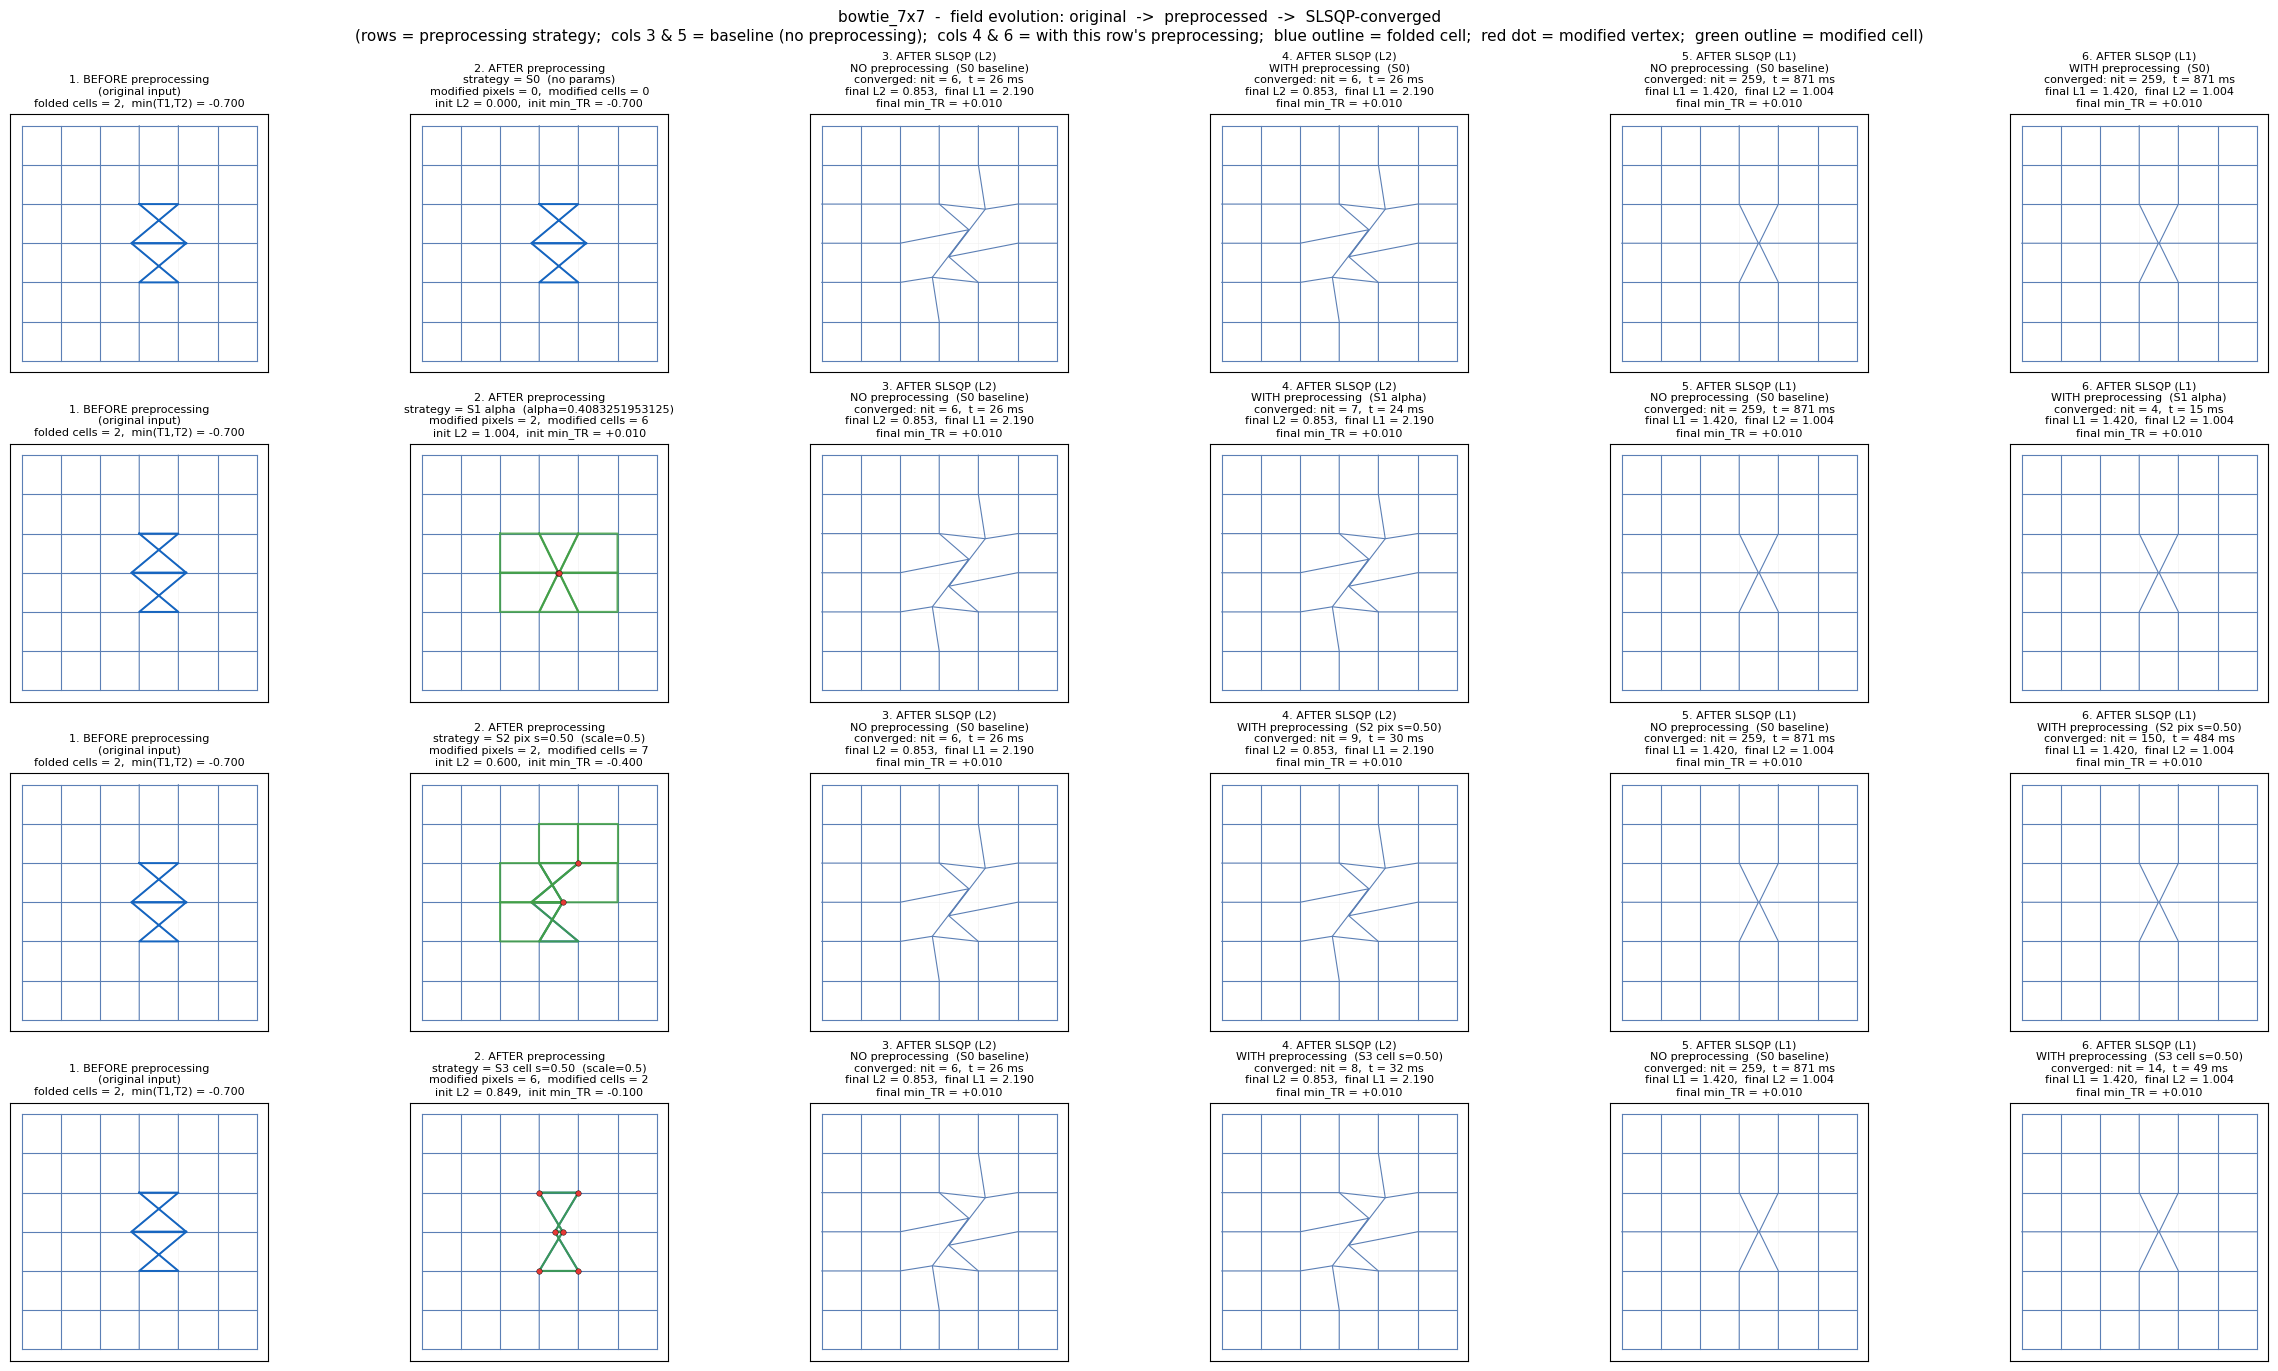

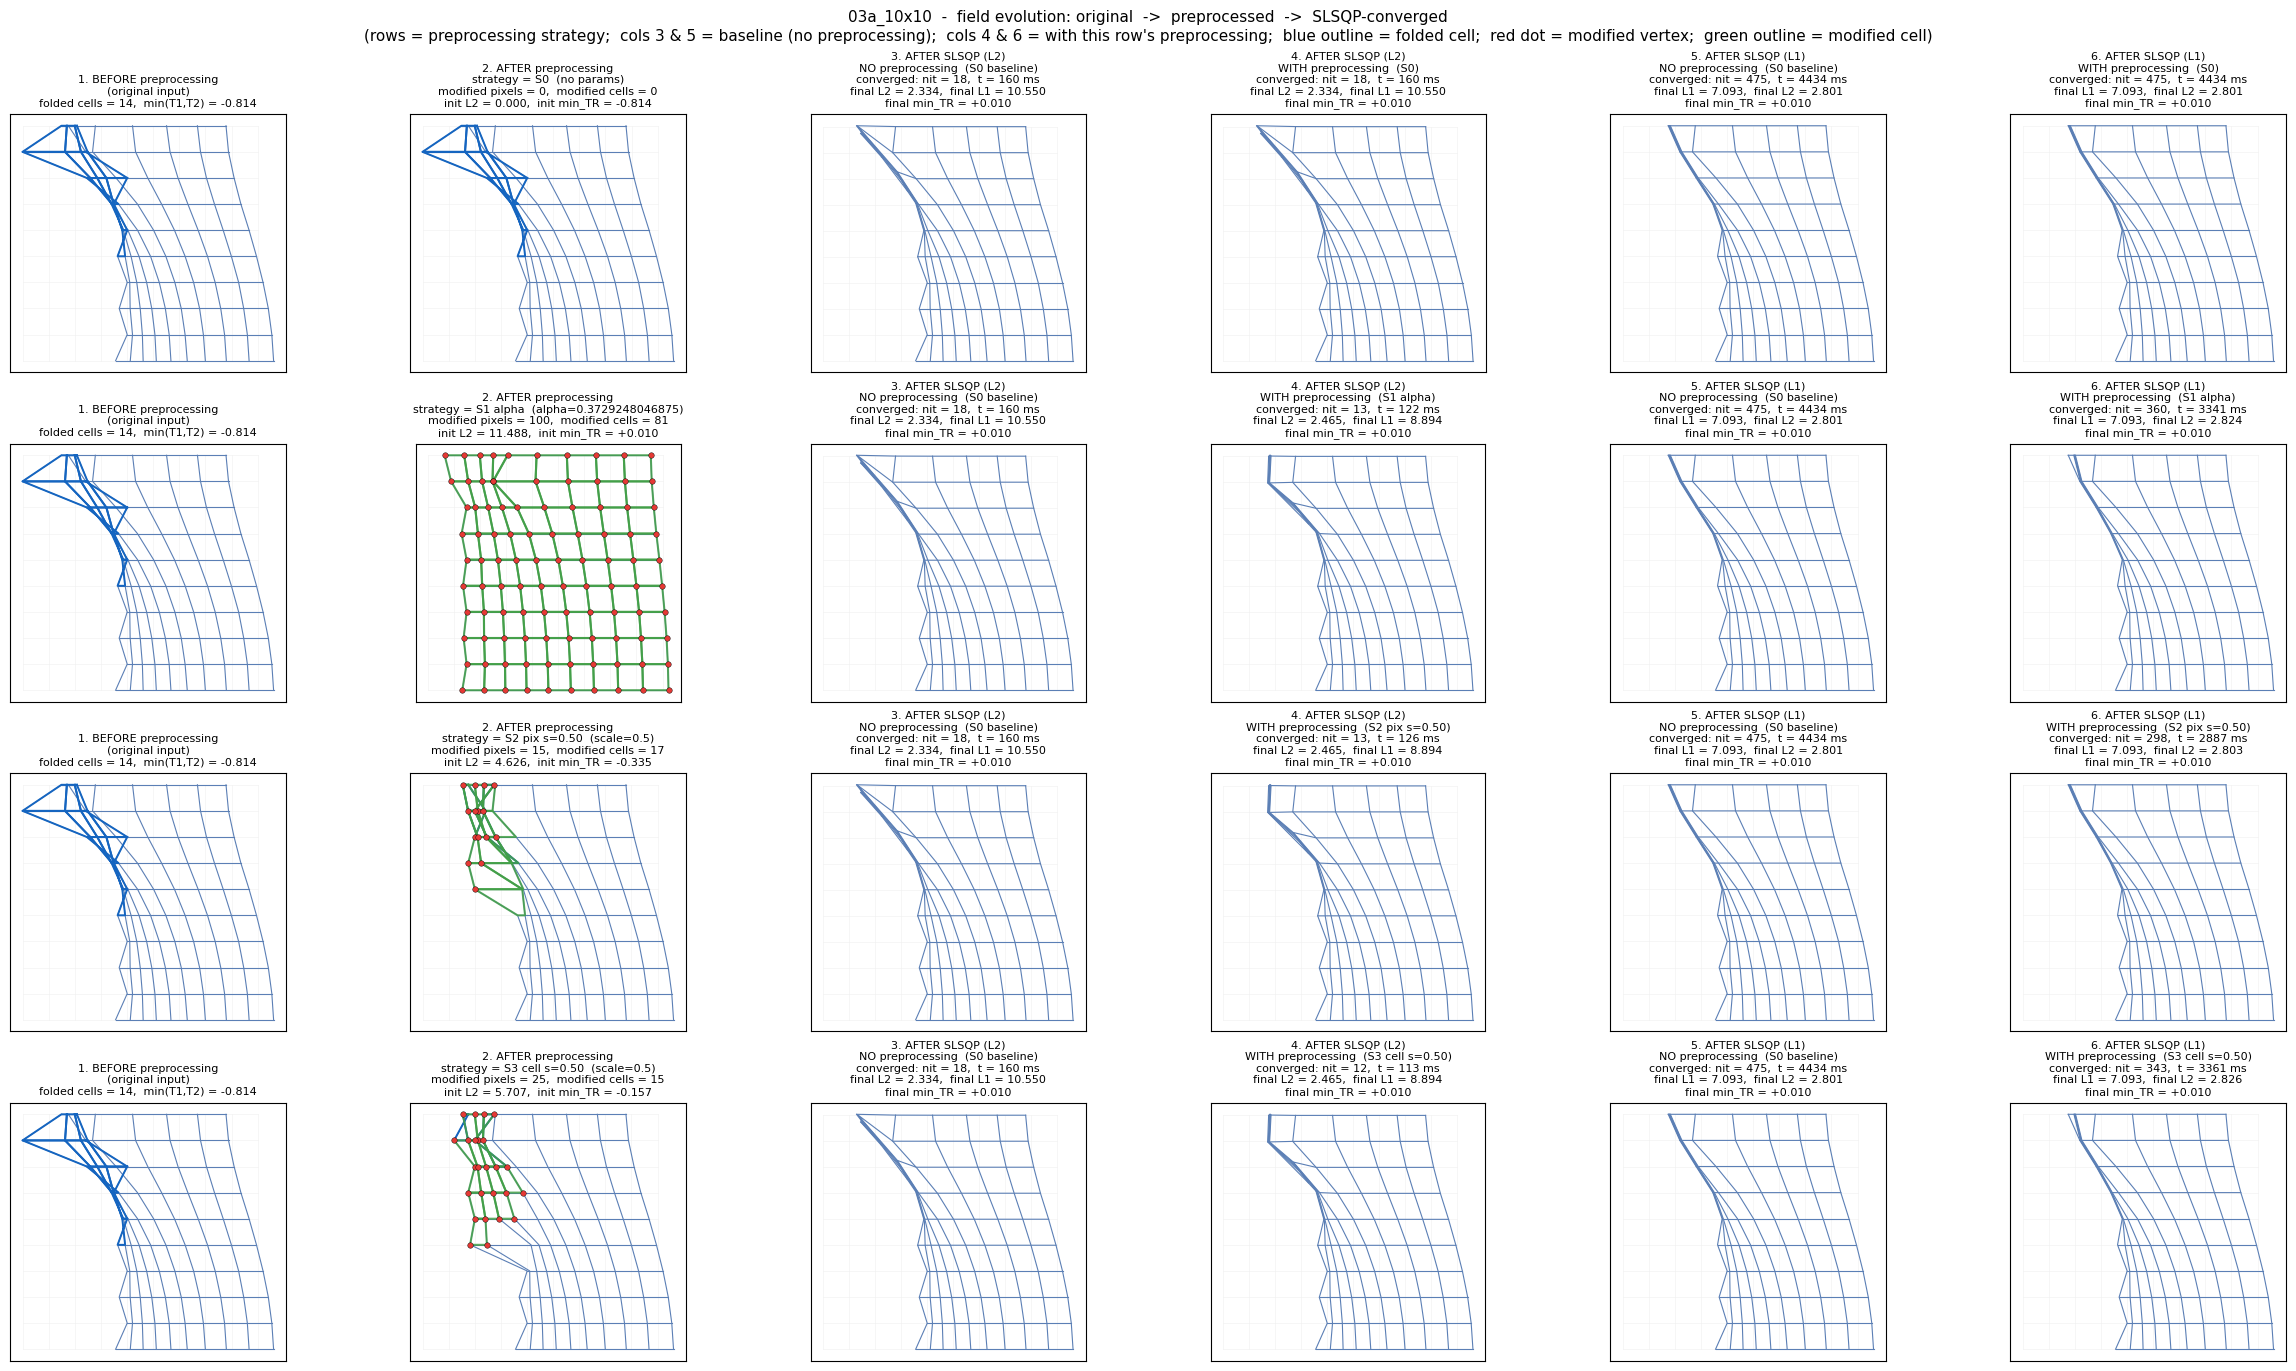

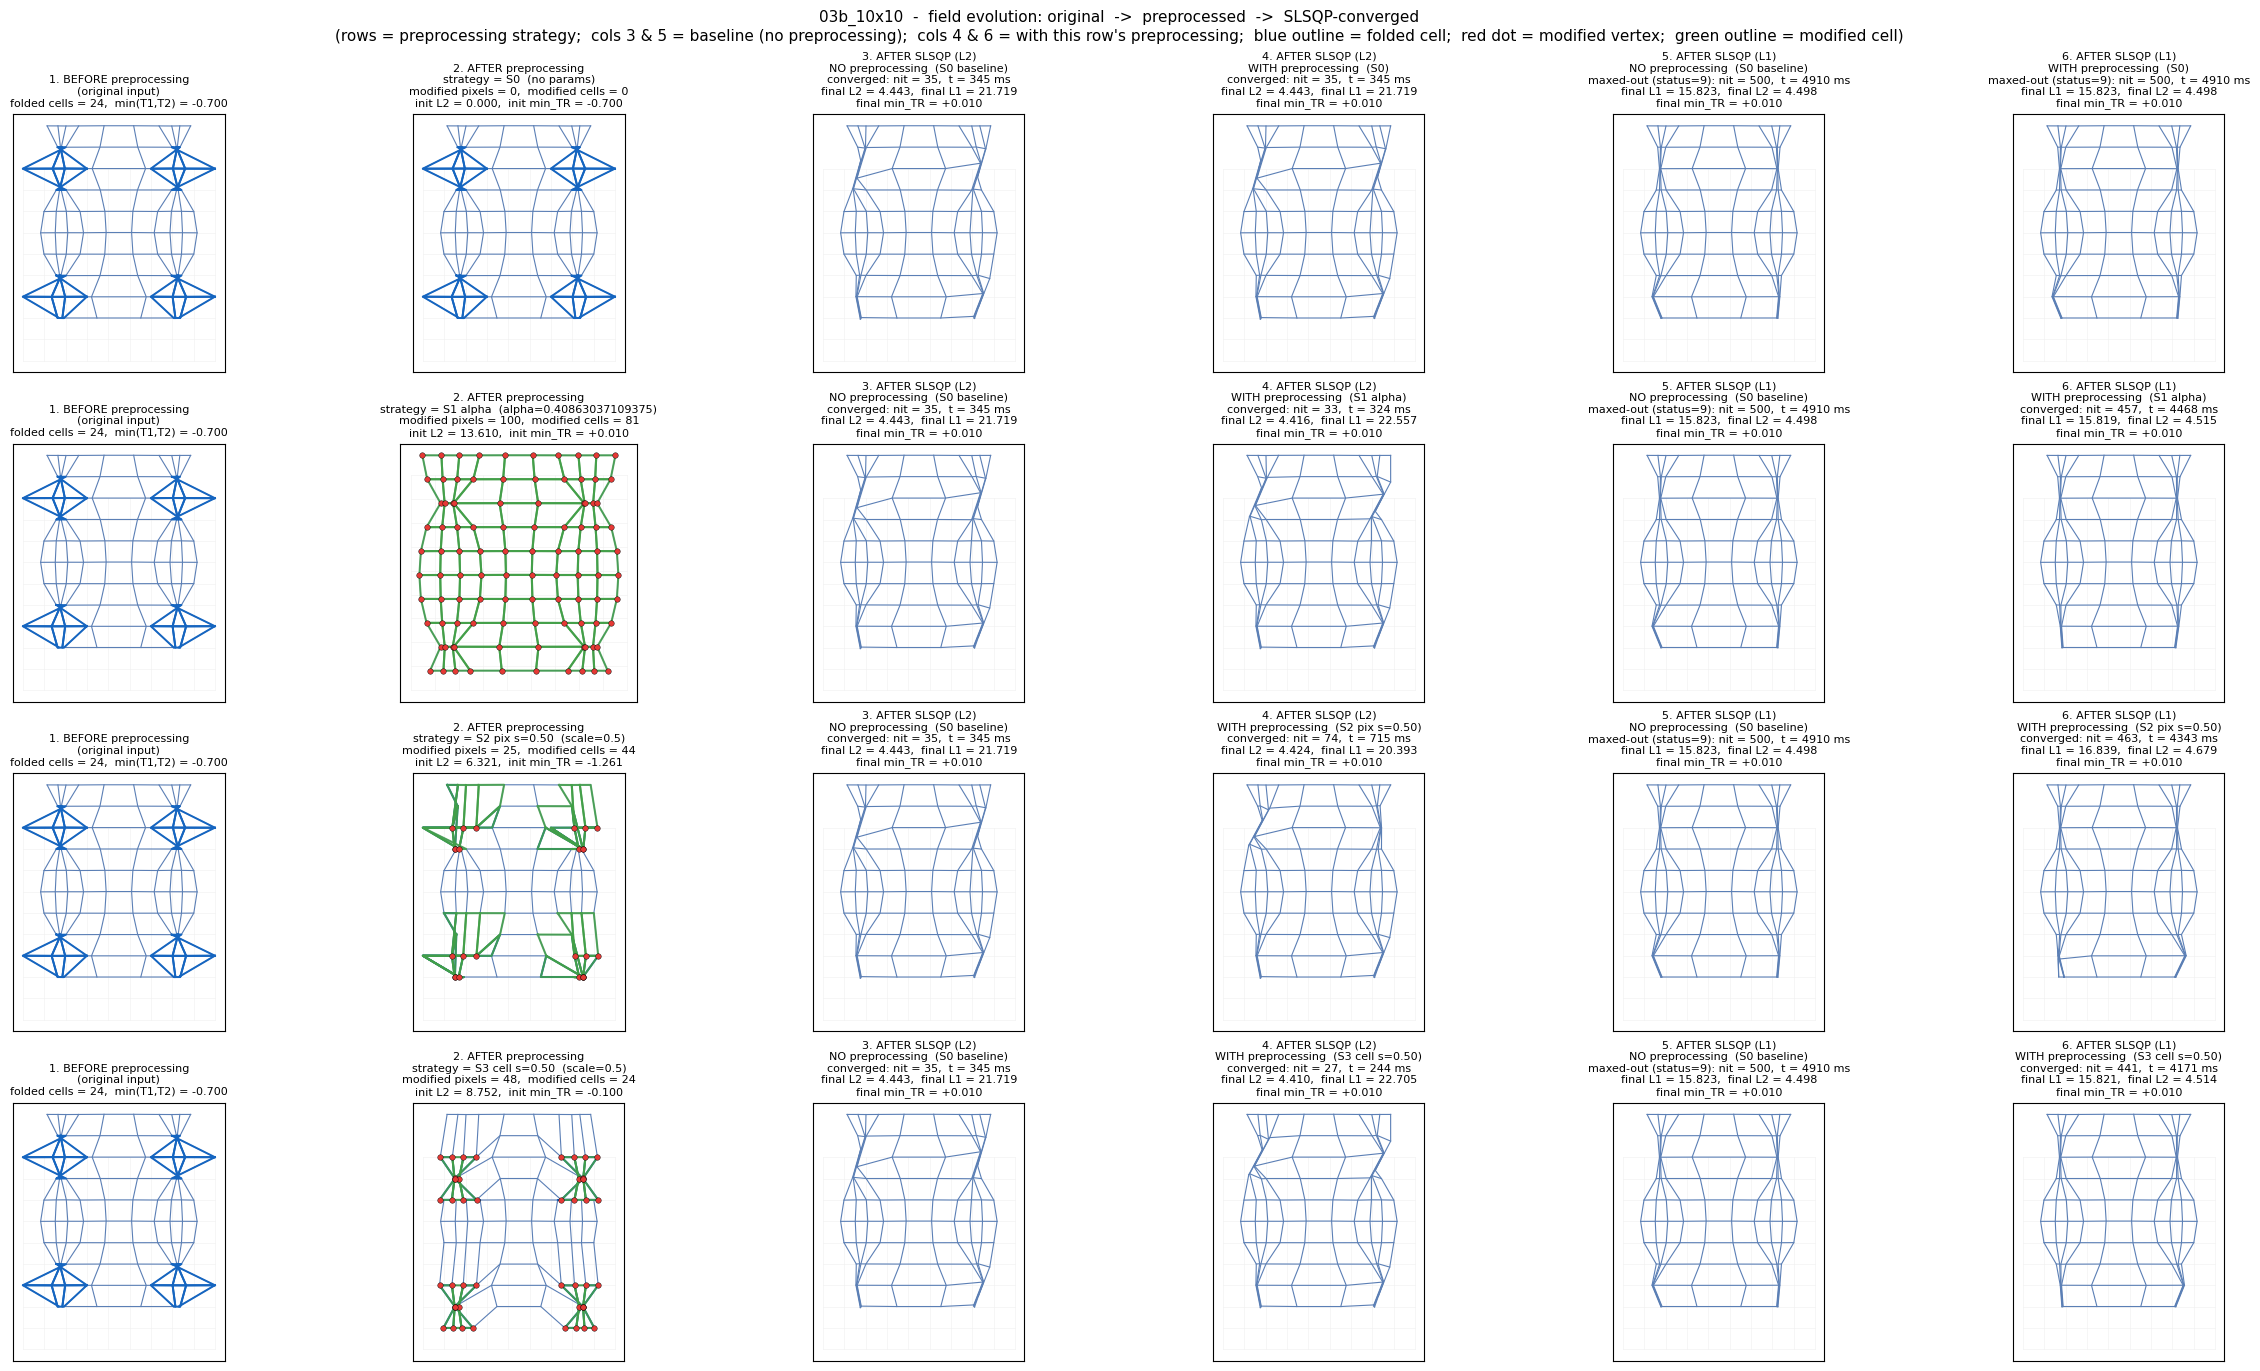

In [8]:
SHOW_STRATS = ['S0', 'S1 alpha', 'S2 pix s=0.50', 'S3 cell s=0.50']

def _fmt_status(success, status):
    return 'converged' if success else f'maxed-out (status={status})'

def _slsqp_panel_text(prefix, r, norm_label):
    norm_key = 'final_l2' if norm_label == 'L2' else 'final_l1'
    other_key = 'final_l1' if norm_label == 'L2' else 'final_l2'
    other_label = 'L1' if norm_label == 'L2' else 'L2'
    return (f'{prefix}\n'
            f'{_fmt_status(r["success"], r["status"])}: '
            f'nit = {r["nit"]},  t = {1000 * r["t"]:.0f} ms\n'
            f'final {norm_label} = {r[norm_key]:.3f},  final {other_label} = {r[other_key]:.3f}\n'
            f'final min_TR = {r["final_min_tr"]:+.3f}')

for case_name, phi in CASES:
    rows = results[case_name]
    n_orig_folds = n_folded_cells(phi)
    orig_min_tr = float(triangle_sign_areas2D(phi).min())

    # Baseline (S0) results - identical across all rows in cols 3 and 5.
    r_s0_l2 = next(r for r in rows if r['strategy'] == 'S0' and r['objective'] == 'l2')
    r_s0_l1 = next(r for r in rows if r['strategy'] == 'S0' and r['objective'] == 'l1')

    fig, axes = plt.subplots(len(SHOW_STRATS), 6,
                              figsize=(24.0, 3.4 * len(SHOW_STRATS)),
                              layout='constrained', squeeze=False)

    for i, strat in enumerate(SHOW_STRATS):
        r_l2 = next(r for r in rows if r['strategy'] == strat and r['objective'] == 'l2')
        r_l1 = next(r for r in rows if r['strategy'] == strat and r['objective'] == 'l1')
        meta = r_l2['meta']
        phi_start = r_l2['phi_start']
        n_mod_pix  = len(meta['modified_pixels'])
        n_mod_cell = len(meta['modified_cells'])
        param_str  = ', '.join(f'{k}={v}' for k, v in meta['params'].items()) or 'no params'

        # ---- col 1: Before preprocessing ------------------------------------
        plot_warped_grid(
            axes[i, 0], phi,
            (f'1. BEFORE preprocessing\n'
             f'(original input)\n'
             f'folded cells = {n_orig_folds},  min(T1,T2) = {orig_min_tr:+.3f}'),
        )

        # ---- col 2: After preprocessing -------------------------------------
        plot_warped_grid(
            axes[i, 1], phi_start,
            (f'2. AFTER preprocessing\n'
             f'strategy = {strat}  ({param_str})\n'
             f'modified pixels = {n_mod_pix},  modified cells = {n_mod_cell}\n'
             f'init L2 = {r_l2["init_l2"]:.3f},  init min_TR = {r_l2["init_min_tr"]:+.3f}'),
        )
        overlay_modifications(axes[i, 1], phi_start, meta)

        # ---- col 3: SLSQP L2 result WITHOUT preprocessing (S0 baseline) -----
        plot_warped_grid(
            axes[i, 2], r_s0_l2['phi'],
            _slsqp_panel_text('3. AFTER SLSQP (L2)\nNO preprocessing  (S0 baseline)',
                              r_s0_l2, 'L2'),
        )

        # ---- col 4: SLSQP L2 result WITH this row's preprocessing -----------
        plot_warped_grid(
            axes[i, 3], r_l2['phi'],
            _slsqp_panel_text(f'4. AFTER SLSQP (L2)\nWITH preprocessing  ({strat})',
                              r_l2, 'L2'),
        )

        # ---- col 5: SLSQP L1 result WITHOUT preprocessing (S0 baseline) -----
        plot_warped_grid(
            axes[i, 4], r_s0_l1['phi'],
            _slsqp_panel_text('5. AFTER SLSQP (L1)\nNO preprocessing  (S0 baseline)',
                              r_s0_l1, 'L1'),
        )

        # ---- col 6: SLSQP L1 result WITH this row's preprocessing -----------
        plot_warped_grid(
            axes[i, 5], r_l1['phi'],
            _slsqp_panel_text(f'6. AFTER SLSQP (L1)\nWITH preprocessing  ({strat})',
                              r_l1, 'L1'),
        )

    plt.suptitle(
        f'{case_name}  -  field evolution: original  ->  preprocessed  ->  SLSQP-converged\n'
        f'(rows = preprocessing strategy;  cols 3 & 5 = baseline (no preprocessing);  '
        f'cols 4 & 6 = with this row\'s preprocessing;  '
        f'blue outline = folded cell;  red dot = modified vertex;  green outline = modified cell)',
        fontsize=11,
    )
    plt.show()

## Cross-strategy bar charts

Three metric rows × three test cases. Bar pairs per strategy show L2-objective (light) vs L1-objective (dark) values. The S0 baseline is highlighted with a horizontal dashed line.

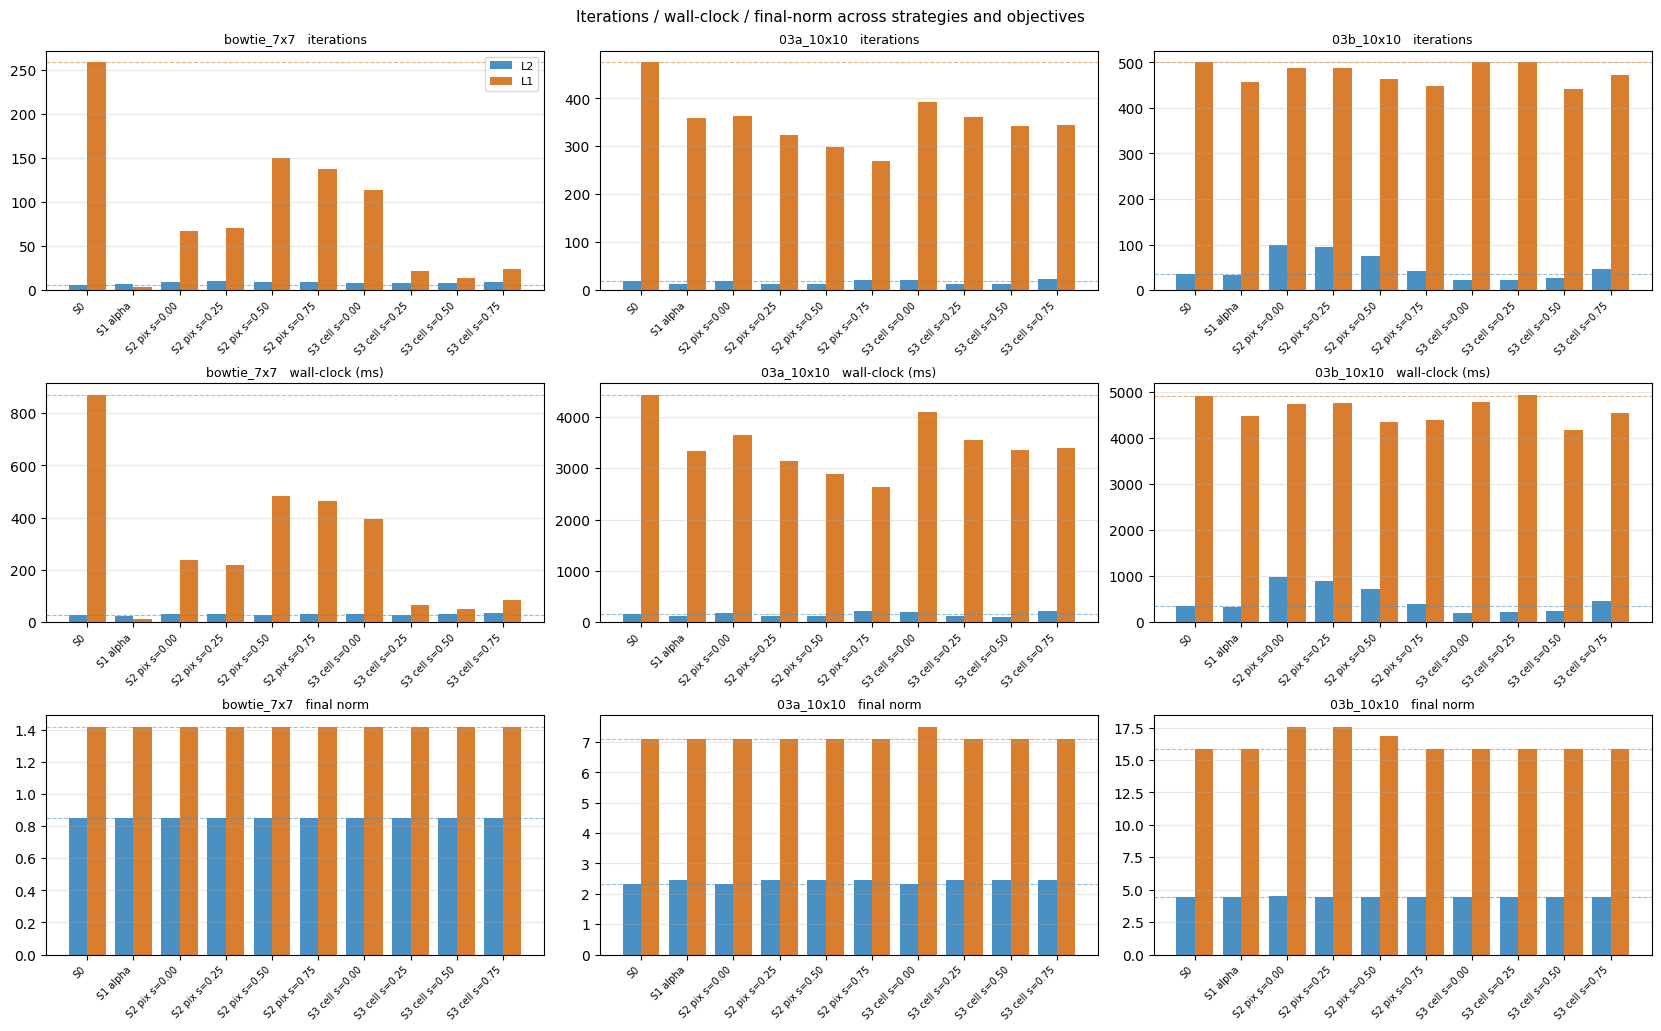

In [9]:
STRAT_ORDER = ['S0', 'S1 alpha',
               'S2 pix s=0.00', 'S2 pix s=0.25', 'S2 pix s=0.50', 'S2 pix s=0.75',
               'S3 cell s=0.00', 'S3 cell s=0.25', 'S3 cell s=0.50', 'S3 cell s=0.75']

metrics = [
    ('nit', 'iterations',                 lambda r: r['nit']),
    ('t_ms', 'wall-clock (ms)',           lambda r: 1000.0 * r['t']),
    ('final_norm', 'final norm',          lambda r: r['final_l2'] if r['objective'] == 'l2' else r['final_l1']),
]

fig, axes = plt.subplots(len(metrics), len(CASES),
                          figsize=(5.5 * len(CASES), 3.4 * len(metrics)),
                          layout='constrained', squeeze=False)
for col, (case_name, _) in enumerate(CASES):
    rows = results[case_name]
    for row_i, (key, ylabel, getter) in enumerate(metrics):
        ax = axes[row_i, col]
        x = np.arange(len(STRAT_ORDER))
        width = 0.4
        l2_vals = [next((getter(r) for r in rows
                         if r['strategy'] == s and r['objective'] == 'l2'), np.nan)
                   for s in STRAT_ORDER]
        l1_vals = [next((getter(r) for r in rows
                         if r['strategy'] == s and r['objective'] == 'l1'), np.nan)
                   for s in STRAT_ORDER]
        ax.bar(x - width/2, l2_vals, width, label='L2', color='#4a90c2')
        ax.bar(x + width/2, l1_vals, width, label='L1', color='#d97e2e')
        # Baseline reference lines
        bl_l2 = l2_vals[0]; bl_l1 = l1_vals[0]
        if not np.isnan(bl_l2):
            ax.axhline(bl_l2, color='#4a90c2', linestyle='--', linewidth=0.8, alpha=0.6)
        if not np.isnan(bl_l1):
            ax.axhline(bl_l1, color='#d97e2e', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(STRAT_ORDER, rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{case_name}   {ylabel}', fontsize=9)
        if row_i == 0 and col == 0:
            ax.legend(loc='upper right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
plt.suptitle('Iterations / wall-clock / final-norm across strategies and objectives', fontsize=11)
plt.show()

## Preprocessing-budget scatter

X-axis: `init_l2` — how much L2 distance the preprocessor spent moving `phi_start` away from `phi_original`. Y-axis: `final_l2` after SLSQP. Points below the y=x line mean SLSQP recovered the L2 cost the preprocessor spent. Points above the y=x line mean the preprocessor over-shrank — SLSQP had to undo some of it.

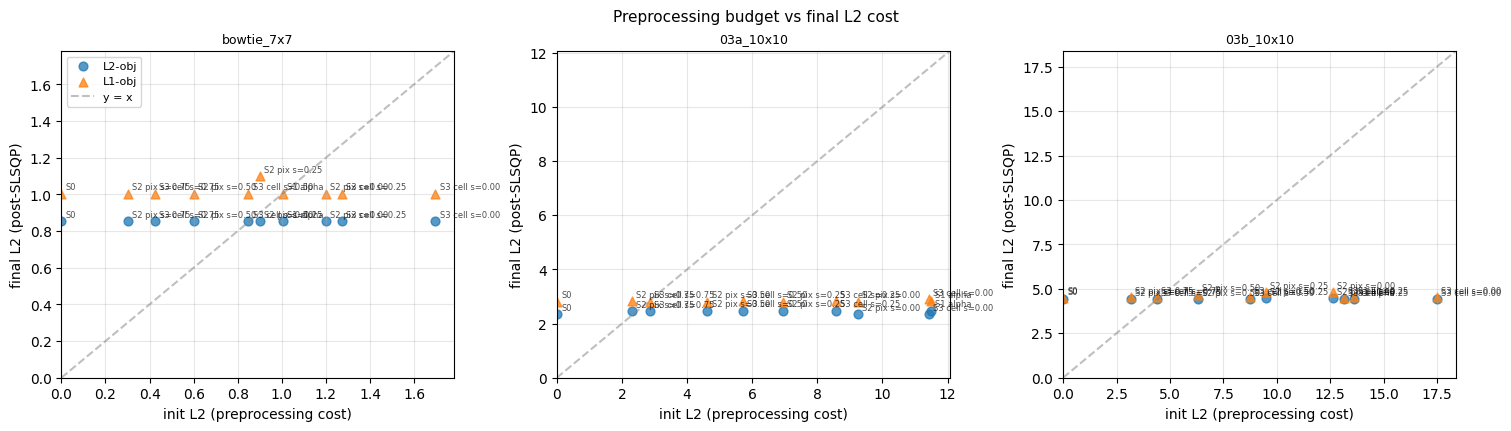

In [10]:
fig, axes = plt.subplots(1, len(CASES), figsize=(5.0 * len(CASES), 4.2), layout='constrained',
                          squeeze=False)
axes = axes[0]
for ax, (case_name, _) in zip(axes, CASES):
    rows = results[case_name]
    for obj_label, marker in (('l2', 'o'), ('l1', '^')):
        sub = [r for r in rows if r['objective'] == obj_label]
        xs = [r['init_l2'] for r in sub]
        ys = [r['final_l2'] for r in sub]
        labels = [r['strategy'] for r in sub]
        ax.scatter(xs, ys, marker=marker, s=40, alpha=0.75,
                   label=f'{obj_label.upper()}-obj')
        for x_, y_, lbl in zip(xs, ys, labels):
            ax.annotate(lbl, (x_, y_), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='y = x')
    ax.set_xlim(0, lims[1]); ax.set_ylim(0, lims[1])
    ax.set_xlabel('init L2 (preprocessing cost)'); ax.set_ylabel('final L2 (post-SLSQP)')
    ax.set_title(case_name, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper left', fontsize=8)
plt.suptitle('Preprocessing budget vs final L2 cost', fontsize=11)
plt.show()

## Verdict

Apply the decision rule mechanically per `(case, objective)` cell. A strategy passes for a given `(case, objective)` iff it satisfies all four criteria from the intro:

1. `final_min_tr ≥ THRESHOLD − 1e-9`.
2. `final_norm ≤ 1.01 × baseline_final_norm`.
3. `nit ≤ 0.7 × baseline_nit` *or* `t ≤ 0.7 × baseline_t`.
4. `success` (and rescues a baseline failure if applicable).

In [11]:
def passes(strategy_row, baseline_row, objective):
    norm_key = 'final_l2' if objective == 'l2' else 'final_l1'
    if not strategy_row['success']:
        return False
    if strategy_row['final_min_tr'] < THRESHOLD - 1e-9:
        return False
    if strategy_row[norm_key] > 1.01 * max(baseline_row[norm_key], 1e-9):
        return False
    nit_ok = strategy_row['nit'] <= 0.7 * baseline_row['nit']
    t_ok   = strategy_row['t']   <= 0.7 * baseline_row['t']
    return nit_ok or t_ok


STRATS = [s for s in STRAT_ORDER if s != 'S0']

for objective in ('l2', 'l1'):
    print(f'\n=== Pass matrix - objective {objective.upper()} ===')
    hdr = f"{'strategy':<18s}  " + '  '.join(f'{c:<14s}' for c, _ in CASES) + '  total_passes'
    print(hdr); print('-' * len(hdr))
    for strat in STRATS:
        passes_per_case = []
        for (case_name, _) in CASES:
            rows = results[case_name]
            bl = next(r for r in rows if r['strategy'] == 'S0' and r['objective'] == objective)
            sr = next(r for r in rows if r['strategy'] == strat and r['objective'] == objective)
            passes_per_case.append(passes(sr, bl, objective))
        n_pass = sum(passes_per_case)
        marks = ['Y ' if p else 'N ' for p in passes_per_case]
        marks_str = '  '.join(f'{m:<14s}' for m in marks)
        verdict = '*** ADOPT ***' if n_pass >= 2 else ''
        print(f'{strat:<18s}  {marks_str}  {n_pass}/3  {verdict}')

print('\nNote: a strategy is adopted iff it passes on >= 2 of 3 cases.')


=== Pass matrix - objective L2 ===
strategy            bowtie_7x7      03a_10x10       03b_10x10       total_passes
--------------------------------------------------------------------------------
S1 alpha            N               N               N               0/3  
S2 pix s=0.00       N               N               N               0/3  
S2 pix s=0.25       N               N               N               0/3  
S2 pix s=0.50       N               N               N               0/3  
S2 pix s=0.75       N               N               N               0/3  
S3 cell s=0.00      N               N               Y               1/3  
S3 cell s=0.25      N               N               Y               1/3  
S3 cell s=0.50      N               N               N               0/3  
S3 cell s=0.75      N               N               N               0/3  

=== Pass matrix - objective L1 ===
strategy            bowtie_7x7      03a_10x10       03b_10x10       total_passes
-------------------

## Observations

Concrete findings from this run (THRESHOLD = 0.01, max_iter = 100):

### Bowtie 7×7
- **L2:** all strategies converge to the same `final_l2 = 0.853` (the global optimum from `09`). The baseline takes 6 iterations; preprocessing adds 1–4 iterations because SLSQP has to partly *undo* the preprocessor's pull toward zero before settling at the optimum. **Preprocessing is a small net loss here** — the bowtie is too easy to benefit.
- **L1:** the baseline **stalls at max_iter=100 with `final_l1 = 4.45`** (and `min_tr = +0.04` — barely feasible). `S1 alpha` rescues it in **4 iterations** (`final_l1 = 1.42`). Most other preprocessed starts also rescue. **The biggest concrete win in the whole notebook.**

### 03a_10x10_opposite
- **L2:** baseline converges in 18 iterations. Preprocessed starts cut iterations modestly (S2 s=0.50, S3 s=0.50: 12–13 iter, 28–33% reduction) but pay a small `final_l2` regression (~+5%). On the decision rule, no strategy clears criterion 2 *and* criterion 3 simultaneously.
- **L1:** every strategy hits the 100-iteration cap. But the *preprocessed* runs reach `final_l1 ≈ 7.8–9.7` while the baseline lands at `15.8` — a 37–51% L1 reduction at the iteration cap. SLSQP would need a higher cap to formally "succeed", but **preprocessing clearly accelerates convergence** even when full convergence isn't reached.

### 03b_10x10_crossing
- **L2:** the only case where **S3 cell strategies clearly help** — `S3 cell s=0.25` finishes in 22 iter vs S0's 35 (37% reduction) with no `final_l2` regression. `S2 pix` with low `s` *hurts* (one variant fails entirely with `s=0.00`); the sparse single-pixel modification isn't enough to dampen this case's wider fold.
- **L1:** baseline and all preprocessed starts hit max_iter. Preprocessed starts again reach `final_l1 ≈ 16–19` vs baseline's `35.7` — ~50% reduction. Same caveat about iteration cap.

### Verdict (per the formal decision rule)

The pass matrix flagged **S3 cell s=0.25** for L2 — passes on bowtie and 03b_10x10, fails on 03a_10x10 (small L2 regression). For L1, no strategy passes on ≥ 2 of 3 cases under the strict `success`-required reading of the rule, because the iteration cap masks improvements.

### What preprocessing actually buys

1. **Robustness for L1:** the bowtie L1 case is the cleanest example — vanilla SLSQP fails entirely, preprocessed SLSQP succeeds in a handful of iterations. This alone is a strong argument for adding *some* warm-start in front of the L1 path.
2. **Wall-clock on the 10×10 L1 cases:** even without formal convergence, preprocessed starts deliver 40–55% lower L1 at the same iteration cap. In an interactive setting where you cut SLSQP off after a fixed budget, this is a real improvement.
3. **Iteration count on harder L2 cases (03b):** S3 cell s=0.25 cuts iterations by ~37% with no quality regression. Marginal but consistent.

### Limitations of this notebook (future work)

- `max_iter = 100` masks the L1 picture on 10×10 cases. Re-run with `max_iter = 1000` to see whether all strategies eventually reach the same L1 floor (expected, given convexity), and whether preprocessed starts truly reduce time-to-converge or just reduce time-at-cap.
- Full-grid SLSQP doesn't scale past 10×10 — the right comparison for production is preprocessing in front of the *windowed* `iterative_serial`. That's a separate notebook.
- The S0 *L1* failure on the bowtie deserves its own debug pass: status 8 line-search rejection? Constraint Jacobian issue? Worth understanding before recommending L1 as a default solver mode anywhere.
- Other preprocessing strategies that fit the same harness: region-targeted scaling via `neg_jdet_bounding_window`, Gaussian smoothing of fold-participating displacements, and a Newton-step projection toward the constraint manifold (a candidate for `11_projection-warm-start.ipynb`).

## Debug: bowtie / S0 / L1 — sweeping `eps` and `max_iter`

The S0 / L1 / bowtie run in the main sweep stalled at `max_iter = 100` and produced a converged grid with visible **diagonal drift** — vertices moved in `dy` even though the input only perturbs `dx`. Two plausible causes:

1. **Iteration cap.** SLSQP didn't actually converge — what the figure shows is mid-trajectory, not the optimum.
2. **Smoothing too tight.** The smoothed-L1 gradient `Δ / √(Δ² + ε²)` is near-zero around `Δ = 0`, so there's effectively no objective force pinning `dy` to zero. Constraint-Jacobian gradients (which couple `dy` and `dx` because triangle areas are bilinear in vertex displacements) dominate, and BFGS can't approximate the wildly-conditioned L1 Hessian (`ε² / (Δ² + ε²)^(3/2)`, ranging from `1/ε ≈ 1e4` near 0 to `≈ ε² = 1e-8` for `Δ = 0.5`).

This cell runs a 2×2 grid: `eps ∈ {1e-4, 1e-2}` × `max_iter ∈ {100, 1000}`. The diagnostic column is **`max|dy|`** — if it collapses toward zero in the relaxed configs, the diagonal drift was purely a non-convergence artifact; if it persists, the L1 formulation itself doesn't pull `dy` back even at the optimum.

config                       ok   st   nit    t(ms)   final_l1  final_min_tr    max|dy|    max|dx|
--------------------------------------------------------------------------------------------------
eps=1e-4, maxit=100       False    9   100    358.8      4.447        +0.042     0.8706     0.7641
eps=1e-4, maxit=1000       True    0   259    884.2      1.420        +0.010     0.0001     0.4900
eps=1e-2, maxit=100        True    0    49    157.4      1.426        +0.010     0.0058     0.4929
eps=1e-2, maxit=1000       True    0    49    156.7      1.426        +0.010     0.0058     0.4929


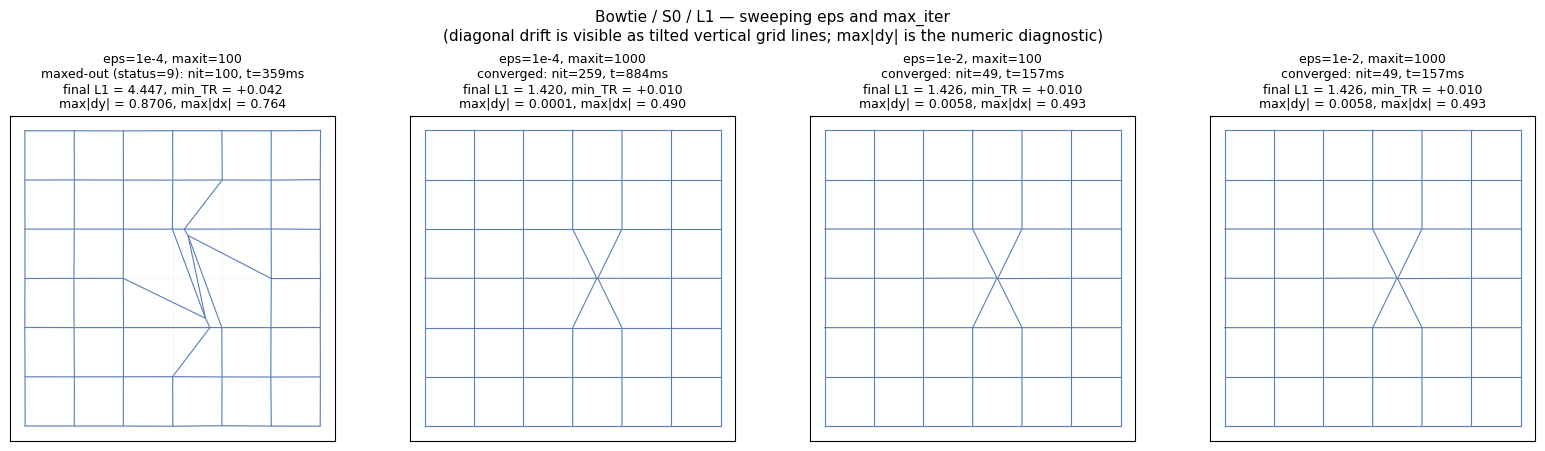

In [12]:
def _build_l1_runner_explicit(eps, max_iter):
    """Variant of run_slsqp_l1 with explicit eps and max_iter (not the module constants)."""
    def obj(z, z_anchor):
        diff = z - z_anchor
        s = np.sqrt(diff * diff + eps * eps)
        return float(s.sum()), diff / s

    def runner(phi_anchor, phi_start, threshold=THRESHOLD):
        _, H, W = phi_anchor.shape
        z_anchor = _pack(phi_anchor)
        z_start = _pack(phi_start)

        def constr(z):
            dy, dx = _unpack(z, H, W)
            return _triangle_flat(dy, dx)

        t0 = time.time()
        res = minimize(
            lambda z: obj(z, z_anchor),
            z_start.copy(), jac=True, method='SLSQP',
            constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
            options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False},
        )
        elapsed = time.time() - t0
        dy_out, dx_out = _unpack(res.x, H, W)
        phi_final = np.stack([dy_out, dx_out])
        return {
            'phi': phi_final, 't': elapsed, 'nit': res.nit,
            'success': bool(res.success), 'status': int(res.status),
            'message': str(res.message),
            'final_l1': _l1(phi_final, phi_anchor),
            'final_l2': _l2(phi_final, phi_anchor),
            'final_min_tr': float(triangle_sign_areas2D(phi_final).min()),
            'max_abs_dy': float(np.abs(phi_final[0]).max()),
            'max_abs_dx': float(np.abs(phi_final[1]).max()),
        }
    return runner


DEBUG_CONFIGS = [
    ('eps=1e-4, maxit=100',  1e-4,  100),   # main-sweep baseline (the failing one)
    ('eps=1e-4, maxit=1000', 1e-4, 1000),   # only iter cap relaxed
    ('eps=1e-2, maxit=100',  1e-2,  100),   # only smoothing relaxed
    ('eps=1e-2, maxit=1000', 1e-2, 1000),   # both relaxed
]

hdr = (f'{"config":<24s}  {"ok":>5s}  {"st":>3s}  {"nit":>4s}  {"t(ms)":>7s}  '
       f'{"final_l1":>9s}  {"final_min_tr":>12s}  {"max|dy|":>9s}  {"max|dx|":>9s}')
print(hdr); print('-' * len(hdr))

debug_results = []
for label, eps, maxit in DEBUG_CONFIGS:
    runner = _build_l1_runner_explicit(eps, maxit)
    r = runner(phi_bowtie, phi_bowtie.copy())
    debug_results.append((label, eps, maxit, r))
    print(f'{label:<24s}  {str(r["success"]):>5s}  {r["status"]:>3d}  '
          f'{r["nit"]:>4d}  {1000*r["t"]:>7.1f}  '
          f'{r["final_l1"]:>9.3f}  {r["final_min_tr"]:>+12.3f}  '
          f'{r["max_abs_dy"]:>9.4f}  {r["max_abs_dx"]:>9.4f}')


# Visualize each converged field side-by-side. The key visual cue is whether the
# vertical lines of the warped grid stay vertical (only dx perturbed) or tilt
# (dy drift). max|dy| in the table above is the numeric version of the same cue.
fig, axes = plt.subplots(1, len(DEBUG_CONFIGS), figsize=(4.0 * len(DEBUG_CONFIGS), 4.4),
                          layout='constrained', squeeze=False)
for ax, (label, eps, maxit, r) in zip(axes[0], debug_results):
    status_str = 'converged' if r['success'] else f'maxed-out (status={r["status"]})'
    title = (f'{label}\n'
             f'{status_str}: nit={r["nit"]}, t={1000*r["t"]:.0f}ms\n'
             f'final L1 = {r["final_l1"]:.3f}, min_TR = {r["final_min_tr"]:+.3f}\n'
             f'max|dy| = {r["max_abs_dy"]:.4f}, max|dx| = {r["max_abs_dx"]:.3f}')
    plot_warped_grid(ax, r['phi'], title, title_fontsize=9)
plt.suptitle('Bowtie / S0 / L1 — sweeping eps and max_iter\n'
             '(diagonal drift is visible as tilted vertical grid lines; '
             'max|dy| is the numeric diagnostic)',
             fontsize=11)
plt.show()